This assignment deals with principal component analysis (PCA) and linear discriminant analysis (LDA).

# PCA
First, you will experiment with PCA. This will also serve as your introduction to the scikit-learn library. For more information about the PCA module in the scikit-learn library, go to http://scikit-learn.org/stable/modules/decomposition.html#decompositions.

One of the basic assumptions of machine learning is that the high dimensional data we observe actually occupies a much lower dimensional manifold. A good description of the low-dimensional manifold is highly desirable. In fact, this is exactly what we try to accomplish when we manufacture *features* for our system. In general, the manifolds will be nonlinear; PCA is an efficient technique for identifying linear, low-dimensional manifolds. 

This idea was exploited when the so-called eigenface approach for facial recognition was developed. Any image lives in a high dimensional space. If the image is $m\times n$, then the dimension of the image space is $mn$. This is huge for even modest resolution images. Since we are, for this application, only interested in facial images, the question arises whether the facial images occupy a lower-dimensional subspace of the huge image space. If that is the case, the next question is how to describe that space, i.e. how do we extract features suitable for describing the space. 

We will briefly explore these idea below.

In [40]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pylab as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Import different modules for using with the notebook
from IPython.display import display
from IPython.display import Image
from IPython.display import HTML

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Run a simple example

In [2]:
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
pcaSimple = PCA(n_components=2)
pcaSimple.fit(X)
print(pcaSimple.explained_variance_ratio_) 

[0.99244289 0.00755711]


### Iris data set
The previous example was just a warm-up. We now turn to the iris data set. The idea is to reproduce the image in the scikit-image website. This is one of the famous data sets widely used in machine learning, and it is included as one of the data sets in scikit-learn. For more information, see  http://archive.ics.uci.edu/ml/datasets/Iris .

This data set represents measurements of 150 iris flowers, along with a response variable (target) indicating which of three iris species each set of measurements corresponds to.  Once the data is loaded, these species (classes) are simply 0, 1, and 2.


In [3]:
from sklearn.datasets import load_iris
iris_data = load_iris()
data = iris_data.data
labels = iris_data.target
classes = set(labels)

print(data.shape)
print(data[:5])

(150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


Fit the data with PCA.  First fit with 3 principal components in order to investigate how much of the variance is explained by the  components.

Make sure you understand and can explain the meaning of `explained variance`, i.e. explain the meaning of the graph below.

[0.92461872 0.05306648 0.01710261]


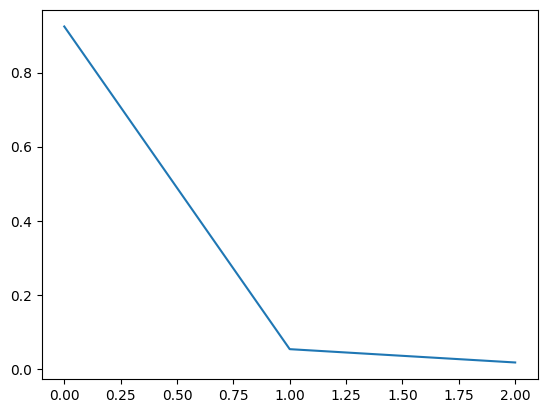

In [4]:
pcaIris = PCA(n_components=3)
pcaIris.fit(data)
print(pcaIris.explained_variance_ratio_)
plt.plot(pcaIris.explained_variance_ratio_)
plt.show()

# Projecting the data.

Project the data onto the first two principal components. Since you have class labels you can plot the 2-dimensional representation of the 3 classes in different colours.  The idea is to see how much class separation is obtained by projecting onto the first two principal components.

You should see something like the following - it will not be exactly the same, since the example image was generated on a subset of the data:

(**You need to provide the code in the following code cell**)

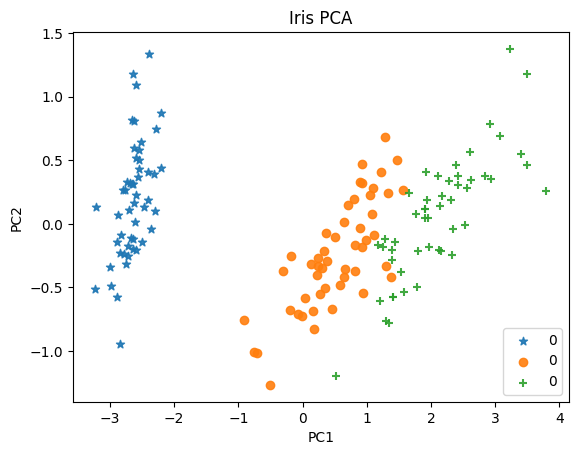

In [5]:
X_pca = pcaIris.fit_transform(data)
target_names = iris_data.target

markers = ['*', 'o', '+']
for cls in np.unique(labels):
    plt.scatter(
        X_pca[labels == cls, 0],
        X_pca[labels == cls, 1],
        marker=markers[cls],
        label=target_names[cls],
        alpha=0.9
    )

plt.title("Iris PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

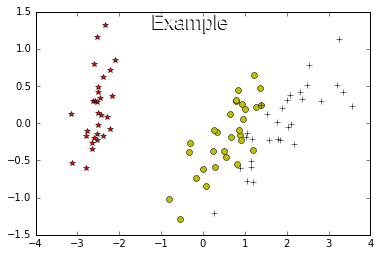

In [6]:
display(Image(filename='../resources/images/Iris_PCA.png'))

### Face recognition

A few years ago, facial recognition using the so-called eigenfaces was very much in fashion, see for example https://en.wikipedia.org/wiki/Eigenface. 


We now briefly explore the main ideas behind the eigenface approach using the Olivetti face database (provided to you as part of the assignment resources). 


First import  all .png files from all the directories inside a specified directory. Each  facial image is then converted to a flat array.


In [7]:
from skimage import io
import glob

image_paths = glob.glob('../data/att_faces/*/*.png')
print(len(image_paths))
images = [io.imread(path) for path in image_paths]
ic = np.array(images)
ic_flat = ic.reshape((len(ic), -1))
number,m,n = ic.shape  

399


### Viewing the faces
Import an image viewer that allows you to step through/view all the loaded images using iPython widgets.

In [8]:
from ipywidgets import interact

print(ic.shape)
print(ic_flat.shape)

def view_image(n=0):
    plt.imshow(ic[n], cmap='gray', interpolation='nearest')
    plt.show()

w = interact(view_image, n=(0, len(ic)-1))

(399, 112, 92)
(399, 10304)


interactive(children=(IntSlider(value=0, description='n', max=398), Output()), _dom_classes=('widget-interact'…

In [9]:
pcaFaces = PCA(n_components=200)
pcaFaces.fit(ic_flat)

PCA(n_components=200)

### The fraction of the total variance captured by the principal directions.

The question arises how many principal components are needed to capture a significant amount of information of a face. For this it is useful to calculate the fraction of the total variance explained by $n$ components. Since this is such a useful quantity to investigate, scikit-learn provides it for us.


Note that the variance drops off very quickly. For something like $n=50$ components a significant proportion of the total variance is already captured. 

**Plot the explained variance.** You should see something like the following:

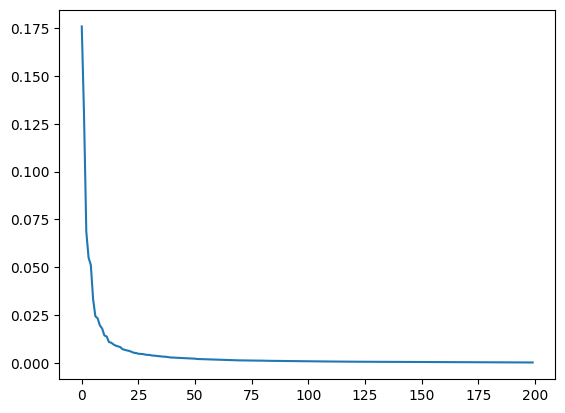

In [10]:
plt.plot(pcaFaces.explained_variance_ratio_)
plt.show()

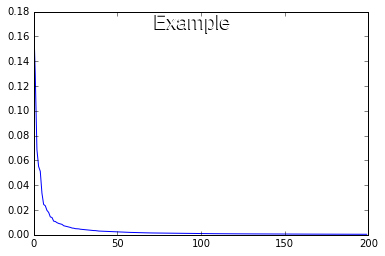

In [11]:
display(Image(filename='../resources/images/Faces_expl_var.png'))

### Projecting the faces onto the eigenfaces.

Now project all the images onto the 200 eigenfaces defined above. In order to visualise how much is lost, the projected images are projected back onto the original space. They are then reshaped and displayed.

In [12]:
pr_ic_flat = pcaFaces.transform(ic_flat)
back_pr_ic_flat = pcaFaces.inverse_transform(pr_ic_flat)

Restore the flattened array into its original shape, then view the restored images.  Keeping in mind that the dimension of the images are reduced from 10304 to 200, the reconstruction is quite good.

In [13]:
ic_restore = back_pr_ic_flat.reshape((number,m,n))

def view_image(n=0):
    plt.imshow(ic_restore[n],cmap='gray', interpolation='nearest')
    plt.show()

w = interact(view_image, n=(0, len(ic)-1))


interactive(children=(IntSlider(value=0, description='n', max=398), Output()), _dom_classes=('widget-interact'…

### Projecting something else

Above, we represented faces used to derive the eigenfaces in terms of the the eigenfaces. Not surprisingly the results are quite good. But the real interest is in faces not part of the training set.

We now project such a face. (See what happens if you try some else's face!)

First read in the face:

In [17]:
ben = io.imread('../resources/images/Ben_bw.png')
ben = np.array(ben)

**Now display the face**. You should see something like:

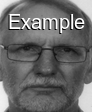

In [18]:
display(Image(filename='../resources/images/Ben_bw_wm.png'))

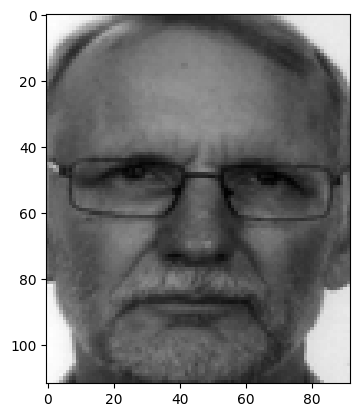

In [19]:
plt.imshow(ben, cmap='gray')
plt.show()

**Flatten the face, project it onto 200 eigenfaces, restore it from the projection, and display.**

You should see something like:

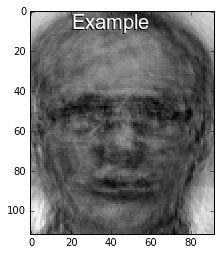

In [20]:
display(Image(filename='../resources/images/Ben_recon.png'))

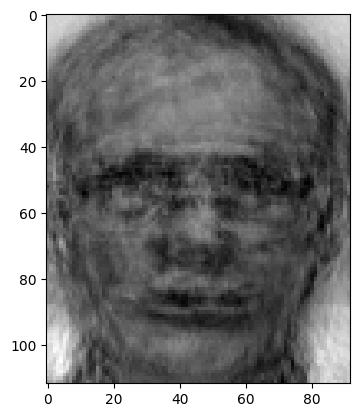

In [21]:
ben_flat = ben.reshape(1, -1)

ben_proj = pcaFaces.transform(ben_flat)
ben_recon_flat = pcaFaces.inverse_transform(ben_proj)
ben_recon = ben_recon_flat.reshape(m, n)

plt.imshow(ben_recon, cmap='gray')
plt.show()

### Signatures

We are also going to use signatures in this course to illustrate various aspects of machine learning. One interesting task is building a signature verification system. One approach to do that is constructing a probabilistic model from a number of training signatures of each signatory (each individual in a database). This probabilistic model should capture and describe the natural variations between different signatures for each signatory. This of course has to be learned from the training signatures.

But signatures also vary as to the origin of whatever coordinate system we use, the size and (in-plane) rotation. It might be possible to also ask the system to recognize signatures at different positions, sizes and rotations, as the same signature. This however, vastly complicates the system and will demand a very large training set representing all these different situations. Instead, it is much easier to do some pre-processing normalizing the signatures. 

Although it will fail on some signatures, PCA is a valuable, simple tool for doing just this. At the same time it provides a great illustration of the underlying mechanism of the singular value decomposition. 

The next exercise will guide you through it.

First we import and display a signature. Feel free to experiment with other signatures.

Note that these signatures were captured on a digitising tablet, capturing the $x$ and $y$ coordinates, the pen pressure, the pen angle(tilt) and the pen direction. For now, we will only use the $x$ and $y$ coordinates, which are the first two features in the provided data.

**Note on the code that you will write:**

You will first calculate the SVD of the signature data (just for the $x,y$ coordinates). Then you will use the SVD factors to successively transform the orignal signature data. First you will simply rotate the data, then you will scale the data so that the standard deviation along the first principal axis equals 1, and finally, you will whiten the data.

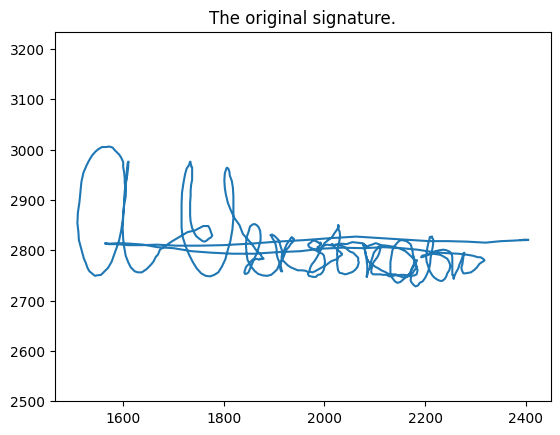

In [22]:
sign_full = np.loadtxt('../data/sign/sign3/sigtrain3_1.txt',comments = '%')  # Read Signature

sign = sign_full[:,:2].T

plt.plot(sign[0,:],sign[1,:])
plt.axis('equal')
plt.title('The original signature.')
plt.show()

### Removing the mean

The first step is to remove the mean of the signature. This centers the signature, i.e. normalizes it with respect to position. 

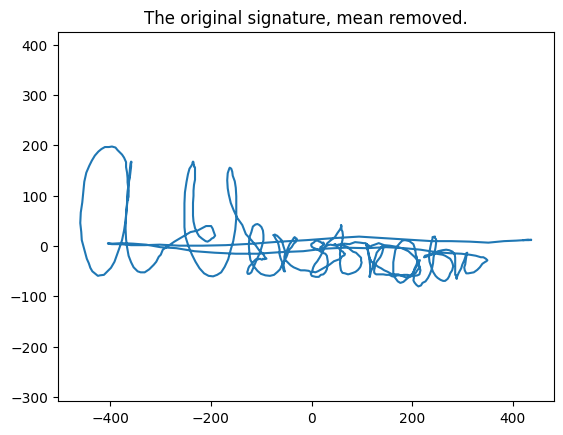

In [23]:
d,n = sign.shape
mean = np.mean(sign,axis=1)[:,np.newaxis]
sign = (sign - mean)

plt.plot(sign[0,:],sign[1,:])
plt.axis('equal')
plt.title('The original signature, mean removed.')
plt.show()

### Calculating the principal components

We calculate the principal components using the SVD. We illustrate the principal directions as well as the one standard deviation by calculating the one standard deviation ellipse, aligned along the principal directions. 

**Getting the sign right**: Since the sign of eigenvectors (principal directions) is not determined, there is no way of predicting whether they are returned with a specific sign. In this case it matters because if the sign is wrong, the signature is reflected around the coordinate axis. It is therefore necessary to check whether the sign is correct, and if not, flip it. The simple expedient used here is to assume that the signatures are produced from left to right. This means that the $x$ component of the first principal direction, and the $y$ component of the second principal direction should both be positive. This will obviously not catch all cases, but should hopefully work for most cases.

Once we have a suitable SVD, the code defines a circle which will be mapped to an ellipse using the covariance of the data (signature).  Have a good look at the details of this calculation.

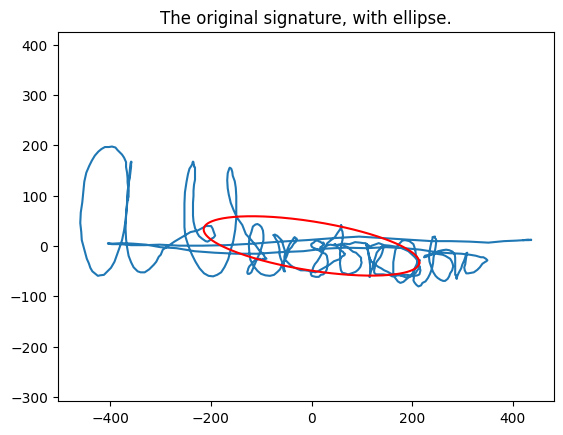

In [24]:
# Calculate the principal directions using the SVD
u, s, vh = np.linalg.svd(sign,full_matrices=False)

sgn = np.sign(u[0,0])
u[:,0] = sgn*u[:,0]
vh[0,:] = sgn*vh[0,:]

sgn = np.sign(u[1,1])
u[:,1] = sgn*u[:,1]
vh[1,:] = sgn*vh[1,:]

# Define Circle
ang = np.linspace(0,2*np.pi,500)
x = np.cos(ang); y = np.sin(ang)
circ = np.vstack((x,y))

# Ellipse aligned with principal directions, one standard deviation intersect.
# Note scaling of singular values so that scaled values express the standard deviations.
ell = u.dot(np.diag(s/np.sqrt(n))).dot(circ)

plt.plot(sign[0,:],sign[1,:])
plt.plot(ell[0,:],ell[1,:],'r')
plt.axis('equal')
plt.title('The original signature, with ellipse.')
plt.show()

### Rotating the signature

**Rotate the signature so that the principal axes coincide with the coordinate axes.**

Do this by using **only** the SVD components. Do **not** rotate by multiplying the original with a rotation matrix.

You should see something like:



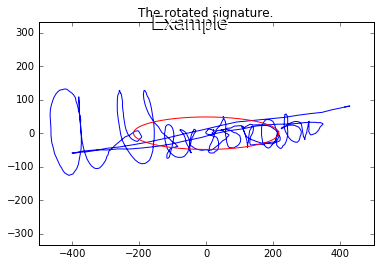

In [25]:
display(Image(filename='../resources/images/sign_rot.png'))

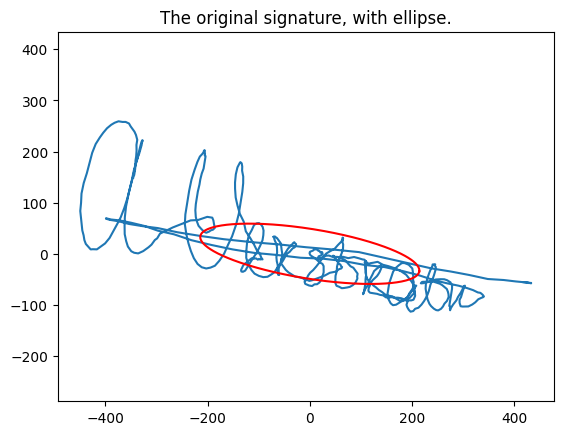

In [27]:
# Insert code to produce the image above
rotated = u @ sign
plt.plot(rotated[0,:],rotated[1,:])
plt.plot(ell[0,:],ell[1,:],'r')
plt.axis('equal')
plt.title('The original signature, with ellipse.')
plt.show()

### Scale the signature

**Scale the signature, preserving the aspect ratio so that the standard deviation along the first principal axis is 1.**

You should see the following (it looks very much like the previous image, except for the scale):

In [ ]:
# Insert code to produce the image below


In [ ]:
display(Image(filename='../resources/images/sign_rot_scale.png'))

### Whiten the signature

**Now scale the signature without preserving the aspect ratio, so that the standard deviations along both principal directions equal 1.**

You should see:

(Note that the ellipse has become a circle!)

In [ ]:
# Insert code to produce the image below


In [ ]:
display(Image(filename='../resources/images/sign_white.png'))

# Some more investigation for PCA


* Above you projected the face not in the database `Ben_bw.png` onto 200 eigenfaces. Now write a function that will take the number of eigenfaces as an parameter to to the reconstruction. Make use of the `interact` function to scroll through the reconstructions as the parameter is varied. Choose the number of components you want to display.

* Use all five features of the signatures. First investigate whether the data is really 5 dimensional by investigating the magnitudes of the singular values.

* Project the 5 dimensional signature onto the first two principal components. Then reconstruct the 5 dimensional signature from the projected data and display the signature again by plotting the (x, y) coordinates. How much information do you lose by projecting down to two dimensions.

In [41]:
class tPCA:
    """
    Principal Component Analysis (PCA) for matrices with shape (d, N).
    
    This implementation follows the CS315 module convention:
    - rows are features/variables (dimension d)
    - columns are observations/samples (count N)
    
    The class supports two fitting routes:
    - `fit_svd`: PCA via singular value decomposition (SVD) of centred data
    - `fit_eigh`: PCA via eigendecomposition of the covariance matrix
    
    Stored attributes after fitting:
    - `x_bar` : feature-wise training mean vector, shape (d,)
    - `principle_components` : matrix whose columns are retained principal directions, shape (d, k)
    - `explained_variance` : eigenvalues for retained components, shape (k,)
    - `explained_variance_ratio` : retained variance fractions, shape (k,)
    """
    
    def __init__(self, n_components=None, whiten=False, ddof=None):
        """
        Initialise PCA hyperparameters and fitted-state placeholders.
        
        Parameters:
        -----------
        n_components : int or None, default=None
            Number of principal components to retain.
            If None, uses the maximum valid value for the chosen fit method.
        whiten : bool, default=False
            If True, transformed coordinates are scaled by inverse standard
            deviation of each retained component.
        ddof : int or None, default=None
            Delta degrees of freedom used in covariance/eigenvalue scaling.
            If None, defaults to 0.
        """
        self.n_components = n_components
        self.whiten = whiten
        self.ddof = 0 if ddof is None else ddof
        
        # Mean vector of features calculated on 'training' data (used for centering)
        self.x_bar = None
        # Columns are principal directions (eigenvectors of covariance matrix)
        self.principle_components = None
        # Eigenvalues of covariance matrix (variance captured per principal component)
        self.explained_variance = None
        # Fraction of total variance explained by each principal component
        self.explained_variance_ratio = None
        
    #===========================================================================
    # External API
    #===========================================================================

    def fit_svd(self, X):
        """
        Perform SVD to derive the principal components and singular values.
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            The input matrix where `d` represents the feature dimension 
            and `N` is the number of observations.
            
        Returns:
        --------
        None
        """
        self._set_n_components(X, method="svd")
        
        # Perform Singular Value Decomposition
        D = self._centre_train(X)
        U, S, V = np.linalg.svd(D, full_matrices=False)
        
        self.principle_components = U[:, :self.n_components]
        singular_values = S[:self.n_components]
        # compute total varaince based on all singular values
        total_variance = np.sum(self._expl_var(S, D.shape[1]))
        self.explained_variance = self._expl_var(singular_values, D.shape[1])
        self._set_expl_var_ratios(total_variance)
        

    def fit_eigh(self, X):
        """
        Perform covariance-based PCA using eigendecomposition.
        
        This method:
        - centres training data
        - builds covariance matrix S = (1/(N-ddof)) * D D^T
        - eigendecomposes S
        - sorts eigenpairs in descending-variance order
        - stores retained principal directions and explained variance data
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            The input matrix where `d` represents the feature dimension
            and `N` is the number of observations.
        
        Returns:
        --------
        None
        """
        self._set_n_components(X, method="eigh")
            
        D = self._centre_train(X)
        S = self._build_cov(D)
        eigenvalues, eigenvectors = np.linalg.eigh(S)
        #sort eigenvalues and eigenvectors in non-increasing order
        eigenvalues = np.flip(eigenvalues)
        eigenvectors = np.fliplr(eigenvectors)
        
        self.principle_components = eigenvectors[:, :self.n_components]
        self.explained_variance = eigenvalues[:self.n_components]
        total_variance = sum(eigenvalues)
        self._set_expl_var_ratios(total_variance)
            
    
    def transform(self, X_new):
        """
        Project data into the fitted principal-component coordinate system.
        
        This method first centres `X_new` with the training mean `x_bar`, then
        projects onto retained principal directions. If whitening is enabled,
        each component score is additionally divided by sqrt(eigenvalue) so
        each retained component has unit variance.
        
        Parameters:
        -----------
        X_new : ndarray of shape (d, M)
            Data to project, where rows are features and columns are
            observations.
        
        Returns:
        --------
        Z : ndarray of shape (k, M)
            Projected coordinates (component scores) in retained PC basis.
        """
        if self.principle_components is None:
            raise Exception("Please fit the PCA First")
        
        D_new = self._centre_oos(X_new)
        if self.whiten:
            if np.any(self.explained_variance <= 0):
                raise ValueError(
                    "Whitening requires strictly positive explained variance "
                    "for all retained components. Reduce n_components or disable whiten."
                )
            A = np.diag(np.ones(shape=len(self.explained_variance)) / np.sqrt(self.explained_variance))
            Z = A @ self.principle_components.T @ D_new
        else: 
            Z = self.principle_components.T @ D_new
        
        return Z
    
    
    def fit_svd_transform(self, X):
        """
        Convenience wrapper equivalent to:
        1) `fit_svd(X)`
        2) `transform(X)`
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            Training data matrix with rows as features and columns as
            observations.
        
        Returns:
        --------
        Z : ndarray of shape (k, N)
            Projected training data in retained PC basis.
        """
        self.fit_svd(X)
        return self.transform(X)
    
    
    def fit_eigh_transform(self, X):
        """
        Convenience wrapper equivalent to:
        1) `fit_eigh(X)`
        2) `transform(X)`
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            Training data matrix with rows as features and columns as
            observations.
        
        Returns:
        --------
        Z : ndarray of shape (k, N)
            Projected training data in retained PC basis.
        """
        self.fit_eigh(X)
        return self.transform(X)
    
    
    def inverse_transform(self, Z):
        """
        Map component scores back to the original feature space.
        
        If whitening was used during `transform`, this method first reverses
        the whitening scale and then reconstructs centred data with the
        retained basis before adding back the training mean vector.
        
        Parameters:
        -----------
        Z : ndarray of shape (k, M)
            Component scores in retained PC basis.
        
        Returns:
        --------
        X_hat : ndarray of shape (d, M)
            Reconstructed data in the original feature space.
        """
        if self.principle_components is None:
            raise Exception("Please fit the PCA First")
        
        if self.whiten:
            A = np.diag(np.sqrt(self.explained_variance))
            Z = A @ Z
        
        D_hat = self.principle_components @ Z
        x_bar_matrix = np.outer(self.x_bar, np.ones(shape=D_hat.shape[1]).T)
        X_hat = D_hat +  x_bar_matrix
        return X_hat


    #===========================================================================
    # Internal Helpers
    #===========================================================================
    
    def _set_n_components(self, X, method):
        """
        Validate and set the number of principal components.
        
        For SVD with X in shape (d, N), at most min(d, N) singular directions
        can be recovered. For covariance eigendecomposition, the maximum count
        is d.
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            Input data matrix using rows=features and columns=observations.
        method : {"svd", "eigh"}
            Fit method being used, which determines the maximum allowable
            number of retained components.
        
        Returns:
        --------
        None
        """
        d, N = X.shape
        max_components = min(d, N) if method == "svd" else d

        if self.n_components is None:
            self.n_components = max_components
            return

        if not isinstance(self.n_components, (int, np.integer)):
            raise TypeError("n_components must be an integer or None")
        if self.n_components <= 0:
            raise ValueError("n_components must be >= 1")
        if self.n_components > max_components:
            raise ValueError(
                f"n_components={self.n_components} exceeds maximum "
                f"allowed ({max_components}) for method='{method}' and "
                f"input shape {X.shape}"
            )

    
    def _centre_train(self, X):
        """
        Centre the data by subtracting the mean vector x_bar from each column.
        
        This method also sets the x_bar class variable
        
        Parameters:
        -----------
        X : ndarray of shape (d, N)
            The input matrix where `d` represents the feature dimension 
            and `N` is the number of observations.
            
        Returns:
        --------
        D : ndarray of shape (d, N)
            The Centred data matrix of the "training" observations
        """
        self.x_bar = np.mean(X, axis=1)
        x_bar_matrix = np.outer(self.x_bar, np.ones(shape=X.shape[1]).T)
        D = X - x_bar_matrix
        return D
    
    
    def _centre_oos(self, X_new):
        """
        Centre out-of-sample data using the stored training mean vector.
        
        Parameters:
        -----------
        X_new : ndarray of shape (d, M)
            New data matrix where rows are features and columns are
            observations.
        
        Returns:
        --------
        D_new : ndarray of shape (d, M)
            Centred out-of-sample data matrix.
        """
        x_bar_matrix = np.outer(self.x_bar, np.ones(shape=X_new.shape[1]).T)
        D_new = X_new - x_bar_matrix
        return D_new


    def _build_cov(self, D):
        """
        Build covariance matrix from centred data.
        
        Covariance is computed as:
            S = (1/(N-ddof)) * D D^T
        where D has shape (d, N), giving S shape (d, d).
        
        Parameters:
        -----------
        D : ndarray of shape (d, N)
            Centred data matrix.
        
        Returns:
        --------
        S : ndarray of shape (d, d)
            Covariance matrix.
        """
        if D.shape[1] - self.ddof <= 0:
            raise ValueError(
                f"Invalid ddof={self.ddof} for N={D.shape[1]}. "
                "Require N - ddof > 0."
            )
        S = (1 / (D.shape[1] - self.ddof)) * (D @ D.T)
        return S
    
    
    def _expl_var(self, sing_vals, N):
        """
        Calculate explained variance as squared singular values divided by (N-ddof).
        Singular values are related to eigenvalues via:
            lambda_i = (sing_vals)_i^2 / (N - ddof)
        
        Parameters:
        -----------
        sing_vals : np.ndarray
            Singular values corresponding to centred data.
        N : int
            The number of observations in the "training" set
        
        Returns:
        --------
        explained_variance : ndarray of shape (len(sing_vals),)
            The explained variance (eigenvalues) based on the provided singular values.
        """
        if N - self.ddof <= 0:
            raise ValueError(
                f"Invalid ddof={self.ddof} for N={N}. Require N - ddof > 0."
            )
        explained_variance = np.empty(len(sing_vals))
        for i, s in enumerate(sing_vals):
            explained_variance[i] = s**2 / (N - self.ddof)
        
        return explained_variance
        
        
    def _set_expl_var_ratios(self, total_variance):
        """
        Set explained variance ratios as:
            explained_variance[i] / sum(explained_variance)
        
        Parameters:
        -----------
        total_variance : float
            Total variance in the full (non-truncated) eigenspectrum used as
            denominator for ratio computation.
        
        Returns:
        --------
        None, just sets the class variable 'explained_variance_ratio'
        """
        if np.ndim(total_variance) != 0:
            raise ValueError("total_variance must be a scalar.")
        if total_variance <= 0:
            raise ValueError("total_variance must be strictly positive.")

        self.explained_variance_ratio = np.empty(len(self.explained_variance))
        
        for i, lambda_ in enumerate(self.explained_variance):
            self.explained_variance_ratio[i] = lambda_ / total_variance


In [30]:
def frobenius_norm(A, B):
    """
    Calculate Frobenius-norm reconstruction error between two matrices.
    
    This is the absolute error magnitude:
        ||A - B||_F
    A value of 0 means perfect reconstruction/no error.
    
    Parameters:
    -----------
    A : ndarray
        Approximation/predicted matrix.
    B : ndarray
        Reference/ground-truth matrix.

    Returns:
    --------
    err_fro : float
        Frobenius norm of the difference matrix.
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape} and B{B.shape} must match.")

    E = A - B
    err_fro = np.linalg.norm(E, ord="fro")
    return err_fro
        
        
def relative_frobenius_norm(A, B):
    """
    Calculate relative Frobenius-norm error between two matrices.
    
    Relative error is defined as:
        ||A - B||_F / ||B||_F
    where `B` is the reference matrix.

    Parameters:
    -----------
    A : ndarray
        Approximation/predicted matrix.
    B : ndarray
        Reference/ground-truth matrix.

    Returns:
    --------
    rel_err_fro : float
        Relative Frobenius error. Returns:
        - 0.0 if both A and B are zero matrices
        - inf if B is a zero matrix but A is not
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape} and B{B.shape} must match.")

    diff = A - B
    norm_diff = np.linalg.norm(diff, ord="fro")
    norm_ref = np.linalg.norm(B, ord="fro")
    
    if norm_ref == 0:
        return float('inf') if norm_diff != 0 else 0.0
    
    rel_err_fro = norm_diff / norm_ref
    return rel_err_fro


def mse(A, B):
    """
    Calculate mean squared error (MSE) between two matrices.
    
    MSE is computed over all entries:
        mean((A - B)^2)
    
    Parameters:
    -----------
    A : ndarray
        Approximation/predicted matrix.
    B : ndarray
        Reference/ground-truth matrix.

    Returns:
    --------
    mse_val : float
        Mean squared error over all matrix entries.
    """
    if A.shape != B.shape:
        raise ValueError(f"Shape mismatch: A{A.shape} and B{B.shape} must match.")

    E = A - B
    E_squared = np.square(E)
    mse_val = np.mean(E_squared)
    return mse_val


def scree_plot(n_components, explained_variance_ratio, kind=None, threshold=None, color=None):
    """
    Plot explained-variance ratios of retained principal components.
    
    The scree plot can be rendered as bars or a line and optionally includes
    a horizontal threshold reference.
    
    Parameters:
    -----------
    n_components : int
        Number of components to display.
    explained_variance_ratio : ndarray of shape (k,)
        Explained variance ratio values for available components.
    kind : str or None, default=None
        Plot style. Supported values: "bar", "line". If None, uses "bar".
    threshold : float or None, default=None
        Optional horizontal reference value to draw on the plot.
    color : str or None, default=None
        Matplotlib color for the series. If None, defaults to "blue".
    
    Returns:
    --------
    ax : matplotlib.axes.Axes
        Axes object containing the generated scree plot.
    """
    if explained_variance_ratio is None:
        raise ValueError("explained_variance_ratio cannot be None.")
    if not isinstance(n_components, (int, np.integer)):
        raise TypeError("n_components must be an integer.")
    if n_components <= 0:
        raise ValueError("n_components must be >= 1.")
    if n_components > len(explained_variance_ratio):
        raise ValueError(
            f"n_components={n_components} exceeds available explained variance "
            f"entries ({len(explained_variance_ratio)})."
        )
    
    ax = plt.subplot()
    color = "blue" if color is None else color
    pc_names = [f"PC{i + 1}" for i in range(n_components)]
    
    if kind is None or kind.lower() == "bar":
        ax.bar(pc_names, explained_variance_ratio[:n_components], color=color)
    elif kind.lower() == "line":
        ax.plot(pc_names, explained_variance_ratio[:n_components], color=color)
    else:
        raise ValueError(f"kind={kind}, not supported, only bar|line")
    
    if threshold is not None:
        ax.axhline(y=threshold, color="r", linestyle="--", label="Threshold")
    
    ax.set_xlabel("Principal Components")
    ax.set_ylabel("Proportion of explained variance")
    ax.set_title("SCREE Plot")
    
    return ax

# Linear Discriminant Analysis (LDA)

The PCA encountered above can be viewed as a dimensionality reduction scheme, projecting onto the directions with maximal variance.

LDA is also a dimensionality reduction scheme but operates on a very different principle. Now we are given data that are labelled as belonging to different classes: We are given both the input value $x$ and a class label $y$ corresponding to $x$ for each data point. If we have $k$ classes then $y$ will take on one of $k$ values. (In Python, we'll typically use the values 0 through $k-1$.)

The idea is now to project the data onto a lower-dimensional space in such a way that maximal *class separation* is achieved in the lower-dimensional space.  Thus, the axis system we choose will no longer only maximize variance, but it will instead help to more clearly distinguish class membership.

You can learn more about the scikit-learn implementation of LDA at https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html

You will investigate the difference between PCA and LDA using the wine data set - for more information see  http://archive.ics.uci.edu/ml/datasets/Wine. Since the wine dataset is 13-dimensional, the difference between PCA and LDA is more pronounced than with the Iris data set. 

We project down to 2 dimensions for easy visualization. In fact, since there are only 3 classes, one does not retain any more information by using higher dimensions. (Make sure you understand why!)

### Simple example

As a warmup run the example from the scikit-learn website.  What is this code doing?

In [32]:
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
y = np.array([1, 1, 1, 2, 2, 2])
clf = LDA()
clf.fit(X, y)
print(clf.predict([[-0.8, -1]]))

[1]


### Loading the data

Read the data, extract the class labels from the last column, then extract the names of the classes using the convenient `set` type.

In [33]:
wine_train = np.loadtxt('../data/wine/wine_train.txt',delimiter = ',')
wine_train_labels = wine_train[:,-1]
wine_train_classes = list(set(wine_train_labels))
wine_train_classes = np.array(wine_train_classes,dtype=int)
wine_train_labels = np.array(wine_train_labels,dtype = int)
wine_train = wine_train[:,:-1]

wine_test = np.loadtxt('../data/wine/wine_test.txt',delimiter = ',')
wine_test_labels = wine_test[:,-1]
wine_test_classes = list(set(wine_test_labels))
wine_test_classes = np.array(wine_test_classes,dtype=int)
wine_test_labels = np.array(wine_test_labels,dtype = int)
wine_test = wine_test[:,:-1]

### PCA

**Project the data onto 2 PCA components and display the classes of the dimension-reduced data.**

You should see something like:

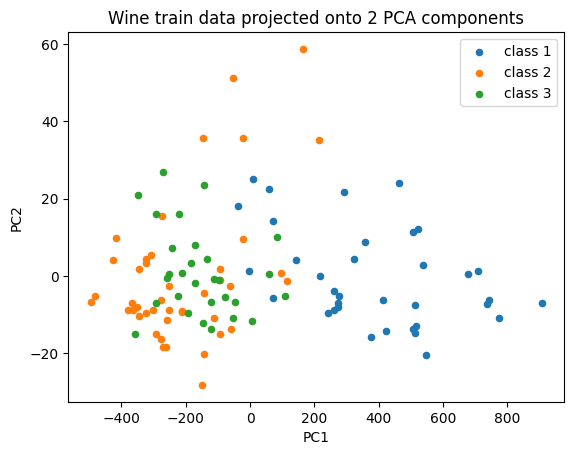

In [45]:
wine_pca = PCA(n_components=2)
X_train_2d = wine_pca.fit_transform(wine_train)
X_test_2d  = wine_pca.transform(wine_test)

# Plot train projection with class coloring
plt.figure()
for c in np.unique(wine_train_labels):
    mask = (wine_train_labels == c)
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1], label=f"class {c}", s=20)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Wine train data projected onto 2 PCA components")
plt.show()

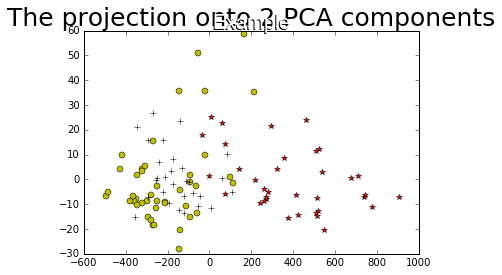

In [35]:
display(Image(filename='../resources/images/Wine_PCA.png'))

### LDA

**Fit an LDA model to the data, using 2 components and display the different classes of the projected data.**

You should see: 

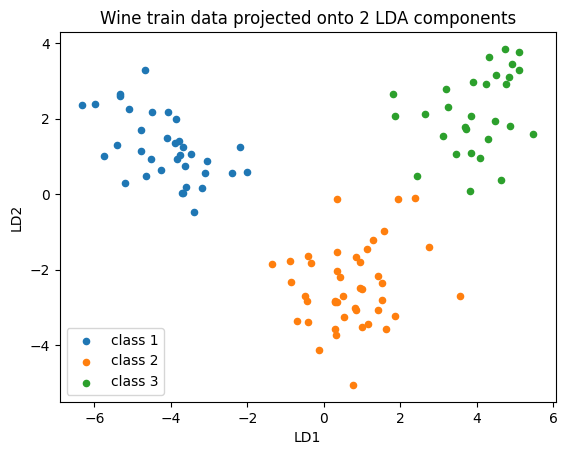

In [47]:
lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(wine_train, wine_train_labels)
X_test_lda  = lda.transform(wine_test)

# Plot train projection with class coloring
plt.figure()
for c in np.unique(wine_train_labels):
    mask = (wine_train_labels == c)
    plt.scatter(X_train_lda[mask, 0], X_train_lda[mask, 1], label=f"class {c}", s=20)

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.title("Wine train data projected onto 2 LDA components")
plt.show()

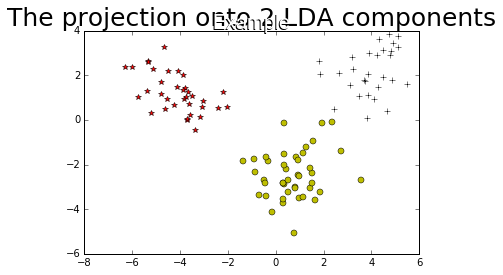

In [37]:
display(Image(filename='../resources/images/LDA_pr.png'))

There should be no doubt that the LDA projection is much better at preserving the class structure.  However, to quantify it, you can use your nearest neighbour classifier from Assignment 0 to compare the classification performance when using the means of the original data, versus transforming data with LDA or PCA.  One way to summarize your findings is with a *confusion matrix*.

In [3]:
class LDA:
    """Linear Discriminant Analysis for dimensionality reduction.

    This implementation follows the convention used in CS315:
        features are rows and observations are columns.
    """

    def __init__(self, n_components=None, normalise=False):
        """Initialize the LDA model.

        Parameters:
        -----------
        n_components : int | None
            Target dimensionality. If None, the maximum valid dimensionality is used.

        Returns:
        --------
        None
        """
        self.n_components = n_components
        self.normalise = normalise

        self.class_labels = None
        self.global_mean = None
        self.class_means = None
        self.transformation_matrix = None
        self.explained_variance_ratio = None
        

    def fit(self, X, y):
        """Fit LDA projection directions from training data.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        LDA
            The fitted model instance.
        """
        X = np.asarray(X)
        y = np.asarray(y)

        # Validate model parameters and input arrays.
        self._validate_input(X, y)

        # Compute means.
        self.global_mean = np.mean(X, axis=1)
        self.class_means = self._compute_class_means(X, y)

        # Compute scatter matrices.
        S_w = self._compute_within_scatter(X, y)
        class_counts = self._compute_class_counts(X, y)
        S_b = self._compute_between_scatter(X.shape[0], class_counts)
        
        if self.normalise:
            S_w = S_w / X.shape[1]
            S_b = S_b / X.shape[1]

        # Compute whitening matrix.
        P = self._compute_whitening(S_w)
        # Whiten S_b.
        S_b_white = P @ S_b @ P.T
        # Compute directions of maximal between-class variance.
        V_k = self._eigendecompose_S_b_white(S_b_white)
        # Compute transformation matrix.
        self.transformation_matrix = P.T @ V_k
        return self
    

    def transform(self, X_new):
        """Project new data into the fitted LDA subspace.

        Parameters:
        -----------
        X_new : np.ndarray
            Matrix of shape ``(n_features, n_new_samples)``.

        Returns:
        --------
        np.ndarray
            Projected matrix of shape ``(n_components, n_new_samples)``.
        """
        X_new = np.asarray(X_new)

        # Validate that LDA has been fitted.
        if self.global_mean is None or self.transformation_matrix is None:
            raise RuntimeError("Call fit before transform.")
        if np.ndim(X_new) != 2:
            raise ValueError(f"LDA expects X_new to be 2D, got {np.ndim(X_new)}D.")
        if X_new.shape[0] != self.global_mean.shape[0]:
            raise ValueError(
                "X_new has incompatible feature dimension: "
                f"expected {self.global_mean.shape[0]}, got {X_new.shape[0]}."
            )

        # Center new data using training global mean.
        D_new = X_new - np.outer(self.global_mean, np.ones(shape=X_new.shape[1]))

        # Project into LDA space.
        Z = self.transformation_matrix.T @ D_new
        return Z


    def fit_transform(self, X, y):
        """Fit the model and return the projected training data.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        np.ndarray
            Projected training matrix of shape ``(n_components, n_samples)``.
        """
        self.fit(X, y)
        return self.transform(X)
    

    def _validate_input(self, X, y):
        """Validate input shapes and model hyperparameters.

        This function also sets class labels for `n_components`
        when the value is not explicitly provided.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        None
        """
        if np.ndim(X) != 2:
            raise ValueError(f"LDA expects X to be 2D, got {np.ndim(X)}D.")
        if np.ndim(y) != 1:
            raise ValueError(f"LDA expects y to be 1D, got {np.ndim(y)}D.")
        if X.shape[1] != y.shape[0]:
            raise ValueError(
                "X and y are misaligned: "
                f"X has {X.shape[1]} samples while y has {y.shape[0]} labels."
            )

        self.class_labels = np.unique(y)
        if len(self.class_labels) < 2:
            raise ValueError("LDA requires at least 2 distinct classes.")

        if self.n_components is not None:
            if not isinstance(self.n_components, (int, np.integer)):
                raise TypeError("n_components must be an integer or None.")
            if self.n_components < 1:
                raise ValueError("n_components must be at least 1.")

        max_components = min(X.shape[0], len(self.class_labels) - 1)
        if self.n_components is None:
            self.n_components = max_components
        elif self.n_components > max_components:
            raise ValueError(
                f"LDA can produce at most {max_components} components, "
                f"got {self.n_components}."
            )


    def _compute_class_means(self, X, y):
        """Compute the mean feature vector for each class.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        np.ndarray
            Class-mean matrix of shape ``(n_features, n_classes)``.
        """
        class_means = []
        for c in self.class_labels:
            mask = (y == c)
            X_c = X[:, mask]
            class_means.append(np.mean(X_c, axis=1))

        return np.column_stack(class_means)


    def _compute_within_scatter(self, X, y):
        """Compute within-class scatter matrix.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        np.ndarray
            Within-class scatter matrix of shape ``(n_features, n_features)``.
        """
        S_w = np.zeros((X.shape[0], X.shape[0]))
        for i, c in enumerate(self.class_labels):
            mask = (y == c)
            X_c = X[:, mask]
            D_c = X_c - np.outer(self.class_means[:, i], np.ones(X_c.shape[1]).T)
            S_w += D_c @ D_c.T

        return S_w


    def _compute_class_counts(self, X, y):
        """Count the number of samples in each class.

        Parameters:
        -----------
        X : np.ndarray
            Training matrix of shape ``(n_features, n_samples)``.
        y : np.ndarray
            Class-label vector of shape ``(n_samples,)``.

        Returns:
        --------
        list[int]
            Per-class sample counts in the order of `self.class_labels`.
        """
        class_counts = []
        for c in self.class_labels:
            mask = (y == c)
            class_counts.append(int(np.sum(mask)))

        return class_counts


    def _compute_between_scatter(self, d, class_counts):
        """Compute between-class scatter matrix.

        Parameters:
        -----------
        d : int
            Number of original features.
        class_counts : list[int]
            Per-class sample counts in the order of `self.class_labels`.

        Returns:
        --------
        np.ndarray
            Between-class scatter matrix of shape ``(d, d)``.
        """
        S_b = np.zeros((d, d))
        for i in range(len(self.class_labels)):
            m_c = self.class_means[:, i] - self.global_mean
            S_b += class_counts[i] * np.outer(m_c, m_c)

        return S_b


    def _compute_whitening(self, S_w, tol=1e-12):
        """Compute whitening matrix for within-class scatter.

        Some near-zero eigenvalues are removed for numerical stability.

        Parameters:
        -----------
        S_w : np.ndarray
            Within-class scatter matrix.
        tol : float
            Relative tolerance used to drop tiny eigenvalues.

        Returns:
        --------
        np.ndarray
            Whitening matrix ``P`` such that ``P @ S_w @ P.T`` is
            approximately identity on the retained subspace.
        """
        # Eigendecompose S_w.
        eigenvalues, eigenvectors = np.linalg.eigh(S_w)

        # Remove near-zero eigenvalues.
        eigenvalues = np.clip(eigenvalues, 0.0, None)
        max_eig = float(np.max(eigenvalues)) if eigenvalues.size else 0.0
        tol_lvl = tol * max(1.0, max_eig)
        keep = eigenvalues > tol_lvl
        if not np.any(keep):
            raise ValueError(
                "Within-class scatter is numerically singular; no stable "
                "whitening directions were found."
            )

        eigenvalues = eigenvalues[keep]
        eigenvectors = eigenvectors[:, keep]

        # Build whitening matrix.
        A = np.diag(1.0 / np.sqrt(eigenvalues))
        P = A @ eigenvectors.T

        return P


    def _eigendecompose_S_b_white(self, S_b_white):
        """Find dominant discriminative directions in whitened space.

        The explained-variance ratio is stored in `self.explained_variance_ratio`.

        Parameters:
        -----------
        S_b_white : np.ndarray
            Whitened between-class scatter matrix.

        Returns:
        --------
        np.ndarray
            Matrix of top eigenvectors with shape
            ``(retained_dims, n_components)``.
        """
        # Eigendecompose whitened between-class scatter.
        eigenvalues, eigenvectors = np.linalg.eigh(S_b_white)

        # Clip tiny negative values and sort descending.
        eigenvalues = np.clip(eigenvalues, 0.0, None)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]

        # Keep top n_components directions.
        eigenvalues_clipped = eigenvalues[:self.n_components]
        V_k = eigenvectors[:, :self.n_components]

        # Compute explained variance ratios safely.
        total_variance = float(np.sum(eigenvalues))
        if total_variance <= 0.0:
            self.explained_variance_ratio = np.zeros(self.n_components)
        else:
            self.explained_variance_ratio = eigenvalues_clipped / total_variance

        return V_k
    


In [ ]:
# Utility functions for LDA
def _validate_xy(X, y):
    """Validate X/y shape alignment for CS315 convention.

    Parameters:
    -------------------
    X : np.ndarray
        Data matrix with shape ``(n_features, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.

    Returns:
    --------------
    tuple[np.ndarray, np.ndarray]
        Sanitized arrays ``(X, y)``.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    if X.ndim != 2:
        raise ValueError(f"Expected X to be 2D, got {X.ndim}D.")
    if y.ndim != 1:
        raise ValueError(f"Expected y to be 1D, got {y.ndim}D.")
    if X.shape[1] != y.shape[0]:
        raise ValueError(
            f"X/y mismatch: X has {X.shape[1]} samples, y has {y.shape[0]} labels."
        )
    return X, y


def compute_class_means(X, y):
    """Compute per-class mean vectors.

    Parameters:
    -------------------
    X : np.ndarray
        Data matrix with shape ``(n_features, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.

    Returns:
    --------------
    tuple[np.ndarray, np.ndarray]
        ``(class_labels, class_means)`` where:
        - ``class_labels`` has shape ``(n_classes,)``
        - ``class_means`` has shape ``(n_features, n_classes)``
    """
    X, y = _validate_xy(X, y)
    class_labels = np.unique(y)
    means = []
    for c in class_labels:
        means.append(np.mean(X[:, y == c], axis=1))
    return class_labels, np.column_stack(means)


def compute_scatter_matrices(X, y):
    """Compute within-class and between-class scatter matrices.

    Parameters:
    -------------------
    X : np.ndarray
        Data matrix with shape ``(n_features, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.

    Returns:
    --------------
    tuple[np.ndarray, np.ndarray]
        ``(S_w, S_b)`` each with shape ``(n_features, n_features)``.
    """
    X, y = _validate_xy(X, y)
    class_labels, class_means = compute_class_means(X, y)
    global_mean = np.mean(X, axis=1)

    d = X.shape[0]
    S_w = np.zeros((d, d))
    S_b = np.zeros((d, d))

    for i, c in enumerate(class_labels):
        X_c = X[:, y == c]
        m_c = class_means[:, i]
        D_c = X_c - m_c[:, None]
        S_w += D_c @ D_c.T
        dm = m_c - global_mean
        S_b += X_c.shape[1] * np.outer(dm, dm)

    return S_w, S_b


def compute_normalized_scatter_matrices(X, y, mode="pooled_mle"):
    """Compute normalized within/between-class scatter matrices.

    Different libraries use different normalization conventions.
    This helper makes those conventions explicit and easy to compare.

    Parameters:
    -------------------
    X : np.ndarray
        Data matrix with shape ``(n_features, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.
    mode : str
        Normalization strategy for ``S_w``:
        - ``"pooled_unbiased"``: ``S_w / (n_samples - n_classes)``
        - ``"pooled_mle"``: ``S_w / n_samples``
        - ``"weighted_class_cov"``: ``sum_k pi_k * cov_k_unbiased``
          where ``pi_k = n_k / n_samples``.

    Returns:
    --------------
    tuple[np.ndarray, np.ndarray]
        ``(S_w_norm, S_b_norm)`` each with shape ``(n_features, n_features)``.
        ``S_b_norm`` is always returned as ``S_b / n_samples``.
    """
    X, y = _validate_xy(X, y)
    S_w, S_b = compute_scatter_matrices(X, y)

    n_samples = X.shape[1]
    class_labels = np.unique(y)
    n_classes = class_labels.size

    if mode == "pooled_unbiased":
        denom = n_samples - n_classes
        if denom <= 0:
            raise ValueError("Need n_samples > n_classes for pooled_unbiased mode.")
        S_w_norm = S_w / denom
    elif mode == "pooled_mle":
        if n_samples <= 0:
            raise ValueError("n_samples must be positive.")
        S_w_norm = S_w / n_samples
    elif mode == "weighted_class_cov":
        d = X.shape[0]
        S_w_norm = np.zeros((d, d))
        for c in class_labels:
            X_c = X[:, y == c]
            n_k = X_c.shape[1]
            if n_k < 2:
                raise ValueError(
                    "Each class must have at least 2 samples in weighted_class_cov mode."
                )
            D_c = X_c - np.mean(X_c, axis=1, keepdims=True)
            cov_k_unbiased = (D_c @ D_c.T) / (n_k - 1)
            S_w_norm += (n_k / n_samples) * cov_k_unbiased
    else:
        raise ValueError(
            "Unknown mode. Use one of: "
            "'pooled_unbiased', 'pooled_mle', 'weighted_class_cov'."
        )

    S_b_norm = S_b / n_samples
    return S_w_norm, S_b_norm


def explained_variance_summary(explained_variance_ratio):
    """Create explained-variance and cumulative-variance summary.

    Parameters:
    -------------------
    explained_variance_ratio : array-like
        Per-component explained-variance ratios.

    Returns:
    --------------
    dict[str, np.ndarray]
        Dictionary with keys:
        - ``component`` (1-based component indices)
        - ``explained_variance_ratio``
        - ``cumulative_explained_variance``
    """
    evr = np.asarray(explained_variance_ratio, dtype=float)
    if evr.ndim != 1:
        raise ValueError("explained_variance_ratio must be a 1D array-like object.")

    return {
        "component": np.arange(1, evr.size + 1),
        "explained_variance_ratio": evr,
        "cumulative_explained_variance": np.cumsum(evr),
    }


def plot_class_scatter_before_lda(
    X,
    y,
    feature_indices=(0, 1),
    feature_names=None,
    ax=None,
    title=None,
    alpha=0.8,
    marker_size=36,
):
    """Plot class-separated scatter before LDA using two original features.

    Parameters:
    -------------------
    X : np.ndarray
        Data matrix with shape ``(n_features, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.
    feature_indices : tuple[int, int]
        Two feature indices to visualize on x/y axes.
    feature_names : list[str] | tuple[str, ...] | None
        Optional feature names for axis labels.
    ax : matplotlib.axes.Axes | None
        Existing axis to draw on. If None, a new figure+axis is created.
    title : str | None
        Plot title. If None, a default title is used.
    alpha : float
        Marker transparency.
    marker_size : float
        Marker size for scatter points.

    Returns:
    --------------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The figure and axis used for plotting.
    """
    X, y = _validate_xy(X, y)

    if len(feature_indices) != 2:
        raise ValueError("feature_indices must contain exactly 2 indices.")
    i, j = int(feature_indices[0]), int(feature_indices[1])
    if i < 0 or j < 0 or i >= X.shape[0] or j >= X.shape[0]:
        raise ValueError(
            f"feature_indices {feature_indices} out of bounds for {X.shape[0]} features."
        )

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    class_labels = np.unique(y)
    cmap = plt.get_cmap("tab10")

    for idx, c in enumerate(class_labels):
        mask = (y == c)
        ax.scatter(
            X[i, mask],
            X[j, mask],
            s=marker_size,
            alpha=alpha,
            color=cmap(idx % 10),
            label=str(c),
        )

    if feature_names is not None and len(feature_names) > max(i, j):
        xlabel = feature_names[i]
        ylabel = feature_names[j]
    else:
        xlabel = f"Feature {i}"
        ylabel = f"Feature {j}"

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title if title is not None else "Before LDA: Class Scatter")
    ax.legend(title="Class")
    ax.grid(alpha=0.2)
    return fig, ax


def plot_lda_projection(
    Z,
    y,
    component_indices=(0, 1),
    ax=None,
    title=None,
    alpha=0.8,
    marker_size=36,
):
    """Plot class-separated scatter in the LDA projected space.

    If `Z` has only one component, the y-axis is set to zeros so samples
    can still be visualized in a 2D scatter.

    Parameters:
    -------------------
    Z : np.ndarray
        Projected matrix with shape ``(n_components, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.
    component_indices : tuple[int, int]
        Two component indices to visualize on x/y axes.
    ax : matplotlib.axes.Axes | None
        Existing axis to draw on. If None, a new figure+axis is created.
    title : str | None
        Plot title. If None, a default title is used.
    alpha : float
        Marker transparency.
    marker_size : float
        Marker size for scatter points.

    Returns:
    --------------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The figure and axis used for plotting.
    """
    Z, y = _validate_xy(Z, y)

    if len(component_indices) != 2:
        raise ValueError("component_indices must contain exactly 2 indices.")
    i, j = int(component_indices[0]), int(component_indices[1])
    if i < 0 or i >= Z.shape[0]:
        raise ValueError(
            f"First component index {i} out of bounds for {Z.shape[0]} components."
        )

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    # Allow 1D projected data by plotting against zeros.
    use_dummy_y = (j >= Z.shape[0]) or (Z.shape[0] == 1)
    y_values = np.zeros(Z.shape[1]) if use_dummy_y else Z[j, :]

    class_labels = np.unique(y)
    cmap = plt.get_cmap("tab10")

    for idx, c in enumerate(class_labels):
        mask = (y == c)
        ax.scatter(
            Z[i, mask],
            y_values[mask],
            s=marker_size,
            alpha=alpha,
            color=cmap(idx % 10),
            label=str(c),
        )

    ax.set_xlabel(f"LD{i + 1}")
    ax.set_ylabel("0" if use_dummy_y else f"LD{j + 1}")
    ax.set_title(title if title is not None else "After LDA: Projected Scatter")
    ax.legend(title="Class")
    ax.grid(alpha=0.2)
    return fig, ax


def plot_before_after_lda(
    X,
    Z,
    y,
    feature_indices=(0, 1),
    component_indices=(0, 1),
    feature_names=None,
    figsize=(13, 5),
):
    """Create side-by-side before/after LDA scatter plots.

    Parameters:
    -------------------
    X : np.ndarray
        Original matrix with shape ``(n_features, n_samples)``.
    Z : np.ndarray
        Projected matrix with shape ``(n_components, n_samples)``.
    y : np.ndarray
        Label vector with shape ``(n_samples,)``.
    feature_indices : tuple[int, int]
        Feature indices for the pre-LDA scatter plot.
    component_indices : tuple[int, int]
        Component indices for the post-LDA scatter plot.
    feature_names : list[str] | tuple[str, ...] | None
        Optional feature names for original-feature axis labels.
    figsize : tuple[float, float]
        Matplotlib figure size.

    Returns:
    --------------
    tuple[matplotlib.figure.Figure, np.ndarray]
        The figure and the two subplot axes.
    """
    X, y = _validate_xy(X, y)
    Z, _ = _validate_xy(Z, y)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    plot_class_scatter_before_lda(
        X,
        y,
        feature_indices=feature_indices,
        feature_names=feature_names,
        ax=axes[0],
        title="Before LDA",
    )
    plot_lda_projection(
        Z,
        y,
        component_indices=component_indices,
        ax=axes[1],
        title="After LDA",
    )
    fig.tight_layout()
    return fig, axes

# Do it yourself!

Much of what you have done above made use of the PCA and LDA libraries.  Now write your own code to perform first PCA and then LDA, and use it to analyze the above data sets (and some others you find online).  The idea is to get a thorough understanding of the process *and intermediate steps* when performing PCA and LDA.  Your implementations can still make use of the SVD or eigenvalue decomposition subroutines (try implementing it with both approaches) - implementing those is outside the scope of this course.

Do some small examples by hand to use as test cases.  If your hand-calculated approach or the result of your implementation differs from those in sklearn, try to figure out why.

Some advice:
* Add an option to perform whitening in the PCA implementation.
* Implement the LDA using your PCA implementation.  To do this, you will need the whitening option above, but also the ability to construct principal components directly from a covariance matrix, rather than the underlying data.  So provide an option to PCA indicating whether you are providing a data matrix or a covariance matrix.
* When performing PCA on a data matrix, you will generally first want to centre the data before calculating the SVD.  When transforming future points, or performing reconstruction, you will need to take the mean into account.